In [1]:
# In this document I will be attempting to make a generalised stencil to calculate the TLM of a function
# This Jupyter notebook is intended to allow easy testing of the individual functions:


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from python_files import base_functions as bf
from python_files import TLM_tests as TT


torch.set_default_dtype(torch.float64)





In [3]:
def spin_up(x, model_parameters, model,spin_up_time):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in = x

    for i in range(spin_up_time):
        x_out = model(x_in, model_parameters)
        # print(x_out.shape)
        x_in = x_out
    return x_out





In [4]:
# We will now define a function that selects the 9 members of each row 
def member_past_selector(grid_index,X,N,ensemble_size):
    subset = torch.zeros(13,ensemble_size)
    for i in range(13):
        j = (grid_index +i - 8)%N
        # print(grid_index, j)
        subset[i,:] = X[j,:]
    return subset

def member_current_selector(grid_index,Xi,N,ensemble_size):
    subset = torch.zeros(1,ensemble_size)
    j = grid_index
    subset[0,:] = Xi[j,:]
    # print(subset.shape)
    return subset

def stencil_selector(grid_index, Ensemble, N, ensemble_size,stencil_members):

    i = grid_index
    print(i)
    print(stencil_members)

    subset = torch.zeros(len(stencil_members), ensemble_size)
    for ii in range(len(stencil_members)):
        j = grid_index + stencil_members[ii]
        print(j)
        subset[(ii%N),:] = Ensemble[(j%N),:]
        

    return subset


In [5]:
# We will now test the stencil_selector function
# we first need to define our ensemble member
# We will now test this functiom
N = 40
ensemble_size = 12

# Row i contains only the value i
X = torch.zeros(N, ensemble_size)

for i in range(N):
    X[i, :] = i

# print(X)


In [6]:
# We will now define the members we want to select:
# i = 10
stencil_members = [-3, -2, 0, 1, 4]
grid_index = 1
Ensemble = X
N = 40
ensemble_size = 12
subset = stencil_selector(grid_index, Ensemble, N, ensemble_size,stencil_members)

print(subset)

1
[-3, -2, 0, 1, 4]
-2
-1
1
2
5
tensor([[38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38., 38.],
        [39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39., 39.],
        [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
        [ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
        [ 5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.]])


In [7]:
def put_in_place(n_i, N, N_tilde, grid_index, stencil_members):
    for i in range(len(stencil_members)):
        local = grid_index + stencil_members[i]
        N_tilde[grid_index, local%N] = n_i[i]
    return N_tilde

In [8]:
N = 40
N_tilde = torch.zeros(N,N)
n_i = [1,2,3,4,5,6,7,8]
stencil_members = [-5,-3, -2,-1,0,2,3,4]
for grid_index in range(N):
    put_in_place(n_i, N, N_tilde, grid_index, stencil_members)


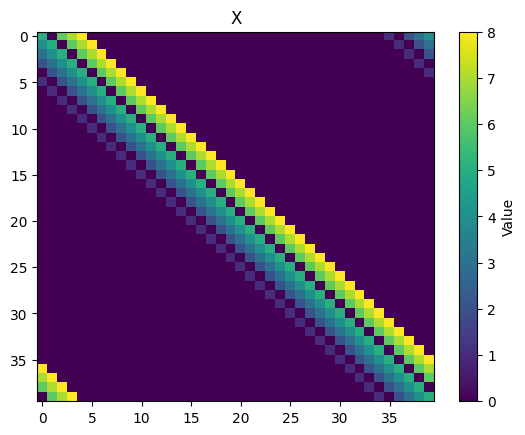

In [9]:
plt.imshow(N_tilde.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X")
plt.show()

In [10]:
def little_IETLM(Xi_i, X_i, stencil_members_large):
    # Construct matrix
    # (1)
    Pi_half = torch.cat((Xi_i, -X_i), dim=0)
    Pi = Pi_half @ Pi_half.T
    # print(Pi_half.shape)

    # (2)
    # Compute smallest eigenpair
    eigenvals, eigenvecs = torch.linalg.eig(Pi)
    # print(eigenvals)

    # Smallest eigenvector (shape: [18])
    
    eigenvals, eigenvecs = torch.lobpcg(Pi, k=1,largest=False)


    # (3)
    # Split into two 9-vectors
    split = len(stencil_members_large[0])
    n_i = eigenvecs[:split]
    l_i = eigenvecs[split:]

    return n_i, l_i




In [11]:
def IETLM_generator(ensemble_size, sd, x_out, model_parameters, model, stencil_members_large):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    N_tilde = torch.zeros(N,N)
    L_tilde = torch.zeros(N,N)

    future_members = stencil_members_large[0]
    current_members = stencil_members_large[1]

    X = torch.zeros(N, ensemble_size)
    Chi = torch.zeros(N, ensemble_size)

    for i in tqdm(range(ensemble_size)):
        x_pert = torch.randn(N,1)*sd
        # print(x_pert)
        x_in_pert = x_out + x_pert
        x_out_pert = model(x_in_pert,model_parameters)
        x_out_unpert = model(x_out, model_parameters)
        Chi_i = x_out_pert - x_out_unpert
        # print("x_out_pert shape:", x_out_pert.shape)
        # print("x_out_unpert shape:", x_out_unpert.shape)
        # print("Chi_i shape:", Chi_i.shape)
        X[:,i] = x_pert.squeeze()
        Chi[:,i] = Chi_i.squeeze()

    for grid_index in range(N):


        X_i = member_past_selector(grid_index,X,N,ensemble_size)
        Chi_i = member_current_selector(grid_index,Chi,N,ensemble_size)

        n_i, l_i = little_IETLM(Chi_i, X_i, stencil_members_large)
        # print(n_i.shape)
        # print(l_i)

        # print(M_i.shape)
        # print(sum(abs(Chi_i - M_i @ X_i)))
        # print(sum(abs(Chi_i[:,0] - M_i @ X_i[:,0])))
        # x_pert_test = torch.randn(N,1)*sd
        # x_pert_test_t1 = model(x_pert_test,model_parameters)


        # print(sum(abs(Chi_i[:,0] - M_i @ X_i[:,0])))
        # print(sum(abs(x_pert_test_t1 - M_i @ x_pert_test)))

        # l_i = [1,2,3,4,5,6,7,8]


        N_tilde = put_in_place(n_i, N, N_tilde, grid_index, future_members)
        L_tilde = put_in_place(l_i, N, L_tilde, grid_index, current_members)


    
    return  N_tilde, L_tilde


In [12]:
dt = 0.01
dx = 0.3
N = 40
n = 2
alpha = 0.5
beta = 0.2
F_96 = 8
model_parameters = (N, dx, dt, alpha, beta, F_96)
ensemble_size = 25
model = bf.rk4_L96
spin_up_time = 1000
sd = 10**(-7)

stencil_members_future = [0]
stencil_members_current = [-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4]
stencil_members_large = [stencil_members_future, stencil_members_current]
# We first need to spin up the model

x_0 = torch.randn(N,1)
x = spin_up(x_0, model_parameters, model, spin_up_time)
x_out = x

N_tilde, L_tilde = IETLM_generator(ensemble_size, sd, x_out, model_parameters, model, stencil_members_large)

100%|██████████| 25/25 [00:00<00:00, 8843.52it/s]


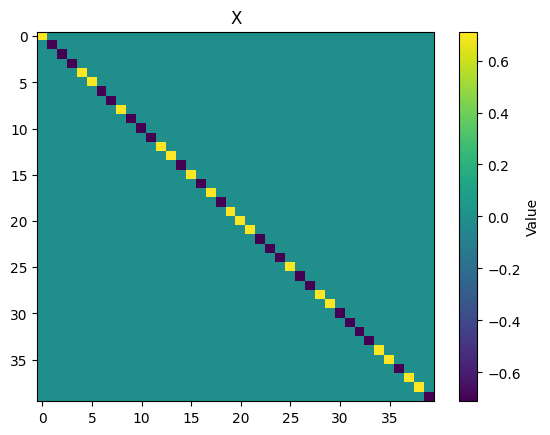

In [13]:
plt.imshow(N_tilde.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X")
plt.show()

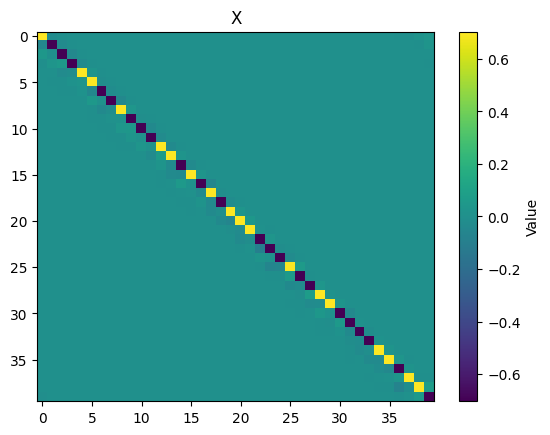

In [14]:
plt.imshow(L_tilde.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X")
plt.show()

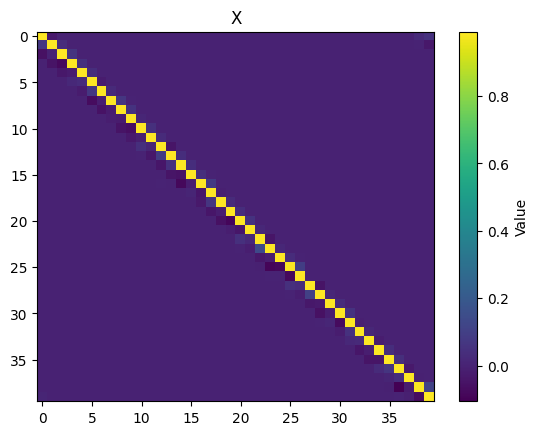

In [15]:
M_tilde = torch.inverse(N_tilde) @ L_tilde
plt.imshow(M_tilde.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X")
plt.show()

In [16]:
dt = 0.01
dx = 0.3
N = 40
n = 2
alpha = 0.5
beta = 0.2
F_96 = 8
model_parameters = (N, dx, dt, alpha, beta, F_96)
ensemble_size = 25
model = bf.CN_L96
spin_up_time = 1000
sd = 10**(-7)

stencil_members_future = [-3,-2,-1,0,1,2,3,4]
stencil_members_current =stencil_members_future # [-2,-1,0,1]
stencil_members_large = [stencil_members_future, stencil_members_current]
# We first need to spin up the model

x_0 = torch.randn(N,1)
x = spin_up(x_0, model_parameters, model, spin_up_time)
x_out = x

N_tilde, L_tilde = IETLM_generator(ensemble_size, sd, x_out, model_parameters, model, stencil_members_large)

100%|██████████| 25/25 [00:00<00:00, 142.55it/s]


IndexError: index 6 is out of bounds for dimension 0 with size 6

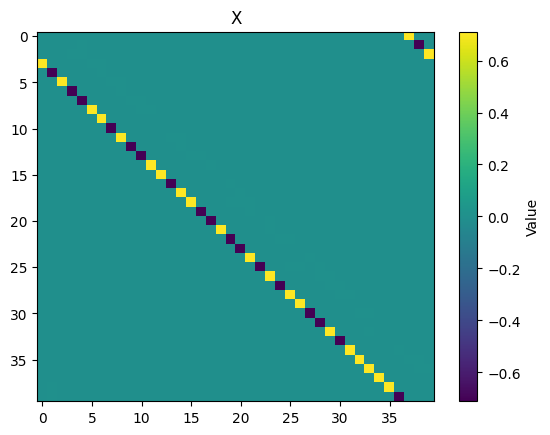

In [ ]:
plt.imshow(N_tilde.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X")
plt.show()

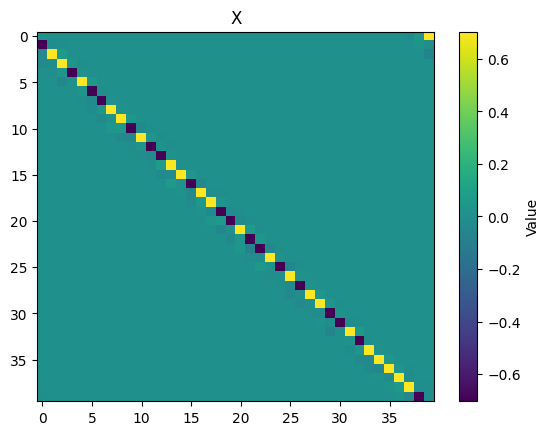

In [ ]:
plt.imshow(L_tilde.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X")
plt.show()

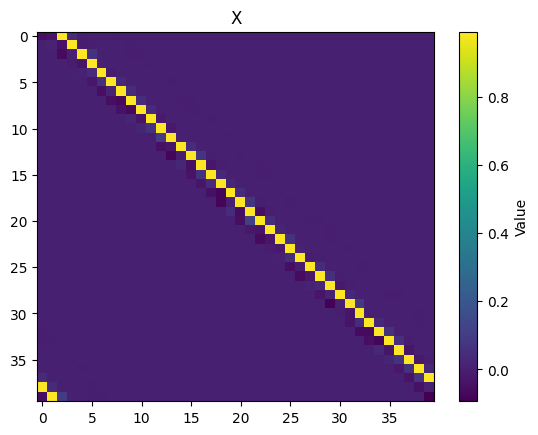

In [ ]:
M_tilde = torch.inverse(N_tilde) @ L_tilde
plt.imshow(M_tilde.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X")
plt.show()